In [1]:
# YOLOv8 설치 (Ultralytics)
# !pip install -q ultralytics


import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from ultralytics import YOLO


print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')


PyTorch: 2.10.0+cu130
Device: cuda


In [3]:
# 사전 학습된 COCO 모델 다운로드 (자동)
# n: nano(가장 빠름) s: small, m: medium l: large, x: extra large
model = YOLO('yolov8n.pt')


In [4]:
print(f'Number of model parameters: {sum(p.numel() for p in model.model.parameters())}')

Number of model parameters: 3157200


In [10]:
# COCO 클래스 (80개)

class_names = model.names
print(f'총 클래스 수: {len(class_names)}')
print(f'일부 클래스: {list(class_names.values())[:10]}')

총 클래스 수: 80
일부 클래스: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


In [11]:
# 테스트 이미지 준비

def download_image(url):
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img
    
    except Exception as e:
        print(f'Error downloading image: {e}')
        return None

In [12]:
test_images = {
    'street': 'https://ultralytics.com/images/bus.jpg',
    'people': 'https://ultralytics.com/images/zidane.jpg',
    'animals': 'https://images.unsplash.com/photo-1583337130417-3346a1be7dee?w=640',
}

street: (810, 1080)
people: (1280, 720)
animals: (640, 800)


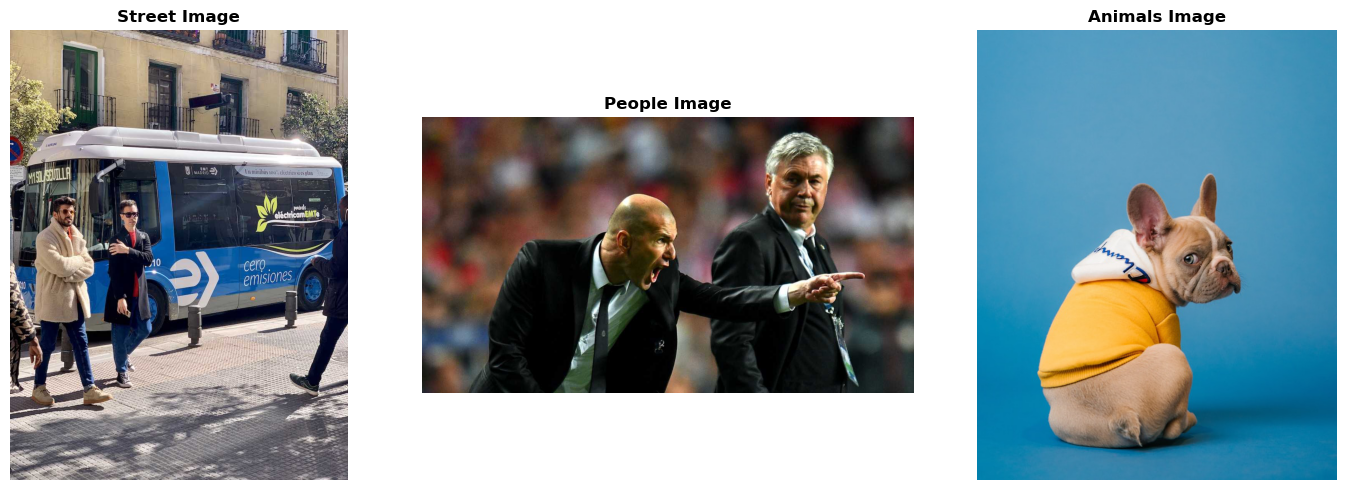

In [13]:
images = {}
for name, url in test_images.items():
    img = download_image(url)
    if img is not None:
        images[name] = img
        print(f'{name}: {img.size}')

if images:
    fig, axes = plt.subplots(1, len(images), figsize=(15,5))
    if len(images) == 1:
        axes = [axes]
    
    for ax, (name, img) in zip(axes, images.items()):
        ax.imshow(img)
        ax.set_title(f'{name.capitalize()} Image', fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [14]:
images.keys()

dict_keys(['street', 'people', 'animals'])

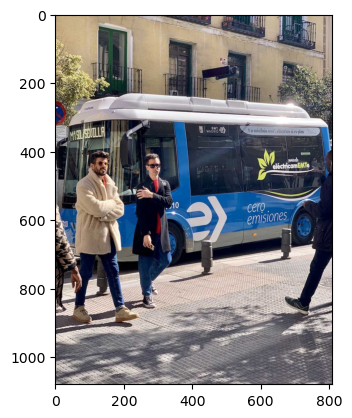

In [15]:
img_name = list(images.keys())[0]
test_img = images[img_name]
plt.imshow(test_img)

In [18]:
results = model(test_img)


0: 640x480 3 persons, 1 bus, 1 stop sign, 2.3ms
Speed: 17.7ms preprocess, 2.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)


In [19]:
result = results[0]

In [23]:
len(results)

1

In [42]:
boxes = result.boxes
len(boxes) # 검출된 객체수

if len(boxes) > 0:
    print("검출상세정보")
    for i, box in enumerate(boxes):
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].cpu().item()
        cls = int(box.cls[0].cpu().item())
        class_name = class_names[cls]

        print(f'{i+1}. {class_name}: {conf:.3f} '
              f"[{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]"
              )

검출상세정보
1. bus: 0.873 [23,231,805,757]
2. person: 0.865 [49,399,245,903]
3. person: 0.853 [669,393,810,877]
4. person: 0.826 [222,406,345,858]
5. stop sign: 0.261 [0,255,32,325]


Yolo v8 해석하는 법

| 형식 | 명칭 | 설명 |
| :--- | :--- | :--- |
| **xywh** | Center Coordinates | 상자의 **중심점(x, y)**과 너비(w), 높이(h) (픽셀 단위) |
| **xywhn** | Normalized Center | 위 데이터를 이미지의 전체 크기(1.0) 대비 비율로 정규화한 값 |
| **xyxy** | Corner Coordinates | 상자의 **좌측 상단(x1, y1)**과 우측 하단(x2, y2) (픽셀 단위) |
| **xyxyn** | Normalized Corner | 위 데이터를 이미지 전체 크기 대비 비율로 정규화한 값 |

In [ ]:
"""
xywh: tensor([[413.9047, 494.0186, 781.9221, 525.4838],
        [146.9182, 650.7156, 196.7146, 503.9226],
        [739.5938, 634.7893, 140.2549, 484.1440],
        [283.3714, 631.6562, 123.2410, 451.7393],
        [ 16.2542, 289.7974,  32.3765,  70.1426]], device='cuda:0')
xywhn: tensor([[0.5110, 0.4574, 0.9653, 0.4866],
        [0.1814, 0.6025, 0.2429, 0.4666],
        [0.9131, 0.5878, 0.1732, 0.4483],
        [0.3498, 0.5849, 0.1521, 0.4183],
        [0.0201, 0.2683, 0.0400, 0.0649]], device='cuda:0')
xyxy: tensor([[2.2944e+01, 2.3128e+02, 8.0487e+02, 7.5676e+02],
        [4.8561e+01, 3.9875e+02, 2.4528e+02, 9.0268e+02],
        [6.6947e+02, 3.9272e+02, 8.0972e+02, 8.7686e+02],
        [2.2175e+02, 4.0579e+02, 3.4499e+02, 8.5753e+02],
        [6.5963e-02, 2.5473e+02, 3.2442e+01, 3.2487e+02]], device='cuda:0')
xyxyn: tensor([[2.8325e-02, 2.1415e-01, 9.9366e-01, 7.0070e-01],
        [5.9952e-02, 3.6922e-01, 3.0281e-01, 8.3581e-01],
        [8.2650e-01, 3.6363e-01, 9.9966e-01, 8.1191e-01],
        [2.7377e-01, 3.7573e-01, 4.2592e-01, 7.9401e-01],
        [8.1436e-05, 2.3586e-01, 4.0052e-02, 3.0080e-01]], device='cuda:0')
"""

In [30]:
len(result)

5

In [32]:
result.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8732, 0.8647, 0.8533, 0.8259, 0.2608], device='cuda:0')
data: tensor([[2.2944e+01, 2.3128e+02, 8.0487e+02, 7.5676e+02, 8.7324e-01, 5.0000e+00],
        [4.8561e+01, 3.9875e+02, 2.4528e+02, 9.0268e+02, 8.6474e-01, 0.0000e+00],
        [6.6947e+02, 3.9272e+02, 8.0972e+02, 8.7686e+02, 8.5330e-01, 0.0000e+00],
        [2.2175e+02, 4.0579e+02, 3.4499e+02, 8.5753e+02, 8.2587e-01, 0.0000e+00],
        [6.5963e-02, 2.5473e+02, 3.2442e+01, 3.2487e+02, 2.6082e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[413.9047, 494.0186, 781.9221, 525.4838],
        [146.9182, 650.7156, 196.7146, 503.9226],
        [739.5938, 634.7893, 140.2549, 484.1440],
        [283.3714, 631.6562, 123.2410, 451.7393],
        [ 16.2542, 289.7974,  32.3765,  70.1426]], device='cuda:0')
xywhn: tensor([[0.5110, 0.4574,

In [33]:
result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

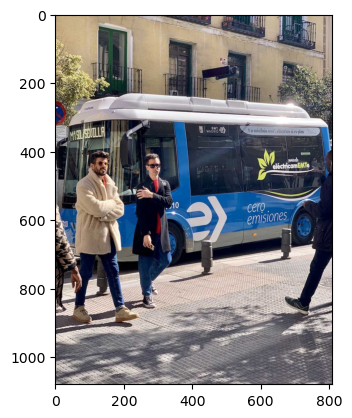

In [40]:
plt.imshow(result.orig_img[:,:,::-1])

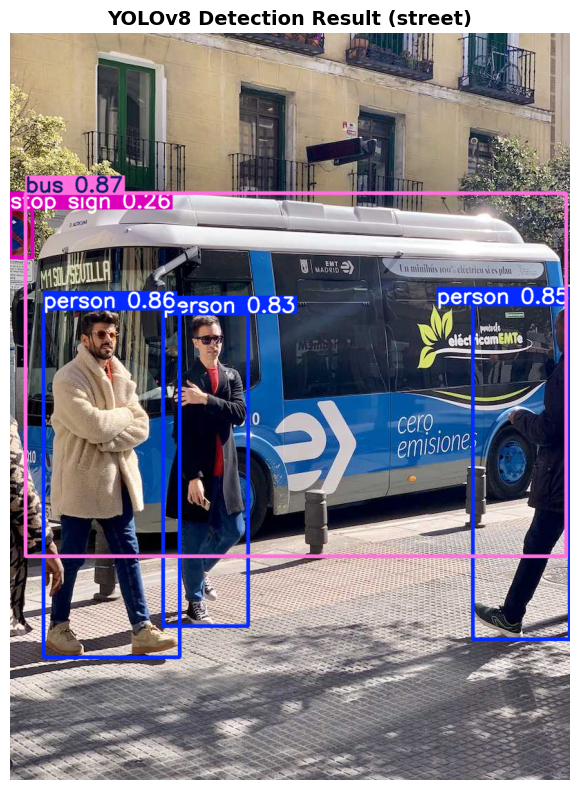

In [45]:
result_img = result.plot()
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result.plot(),cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'YOLOv8 Detection Result ({img_name})',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

confidence threshold 조정


0: 640x480 3 persons, 1 bus, 1 stop sign, 2.2ms
Speed: 20.9ms preprocess, 2.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 3 persons, 1 bus, 5.3ms
Speed: 1.5ms preprocess, 5.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 3 persons, 1 bus, 2.1ms
Speed: 1.0ms preprocess, 2.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)


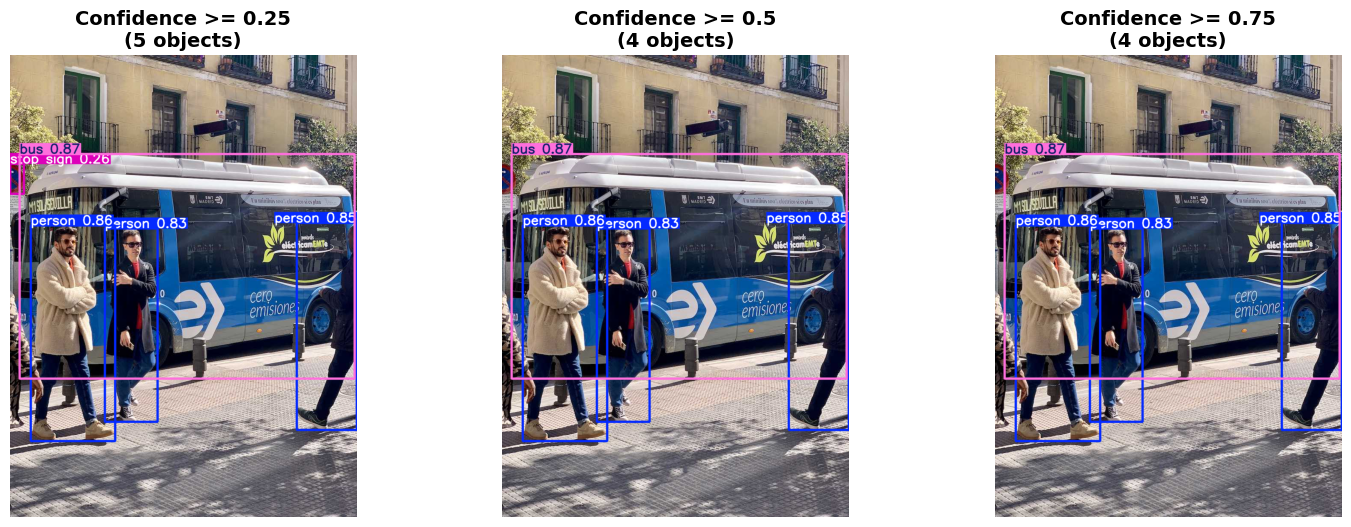

In [48]:
thresholds = [0.25,0.5,0.75]

fig, axes = plt.subplots(1,3,figsize=(18,6))

for ax, conf_thresh in zip(axes, thresholds):
    results_thresh = model(test_img, conf=conf_thresh)
    result_thresh = results_thresh[0] # 첫번째 이미지(근데 입력이 하나 밖에 없긴함)

    img_plot = result_thresh.plot()
    ax.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Confidence >= {conf_thresh}\n'
             f'({len(result_thresh.boxes)} objects)',
             fontsize=14,fontweight='bold')
    ax.axis('off')

plt.tight_layout
plt.show()


0: 640x480 3 persons, 1 bus, 2.4ms
Speed: 9.5ms preprocess, 2.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 2 persons, 2.3ms
Speed: 0.7ms preprocess, 2.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 640x512 1 dog, 2.4ms
Speed: 0.9ms preprocess, 2.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 512)


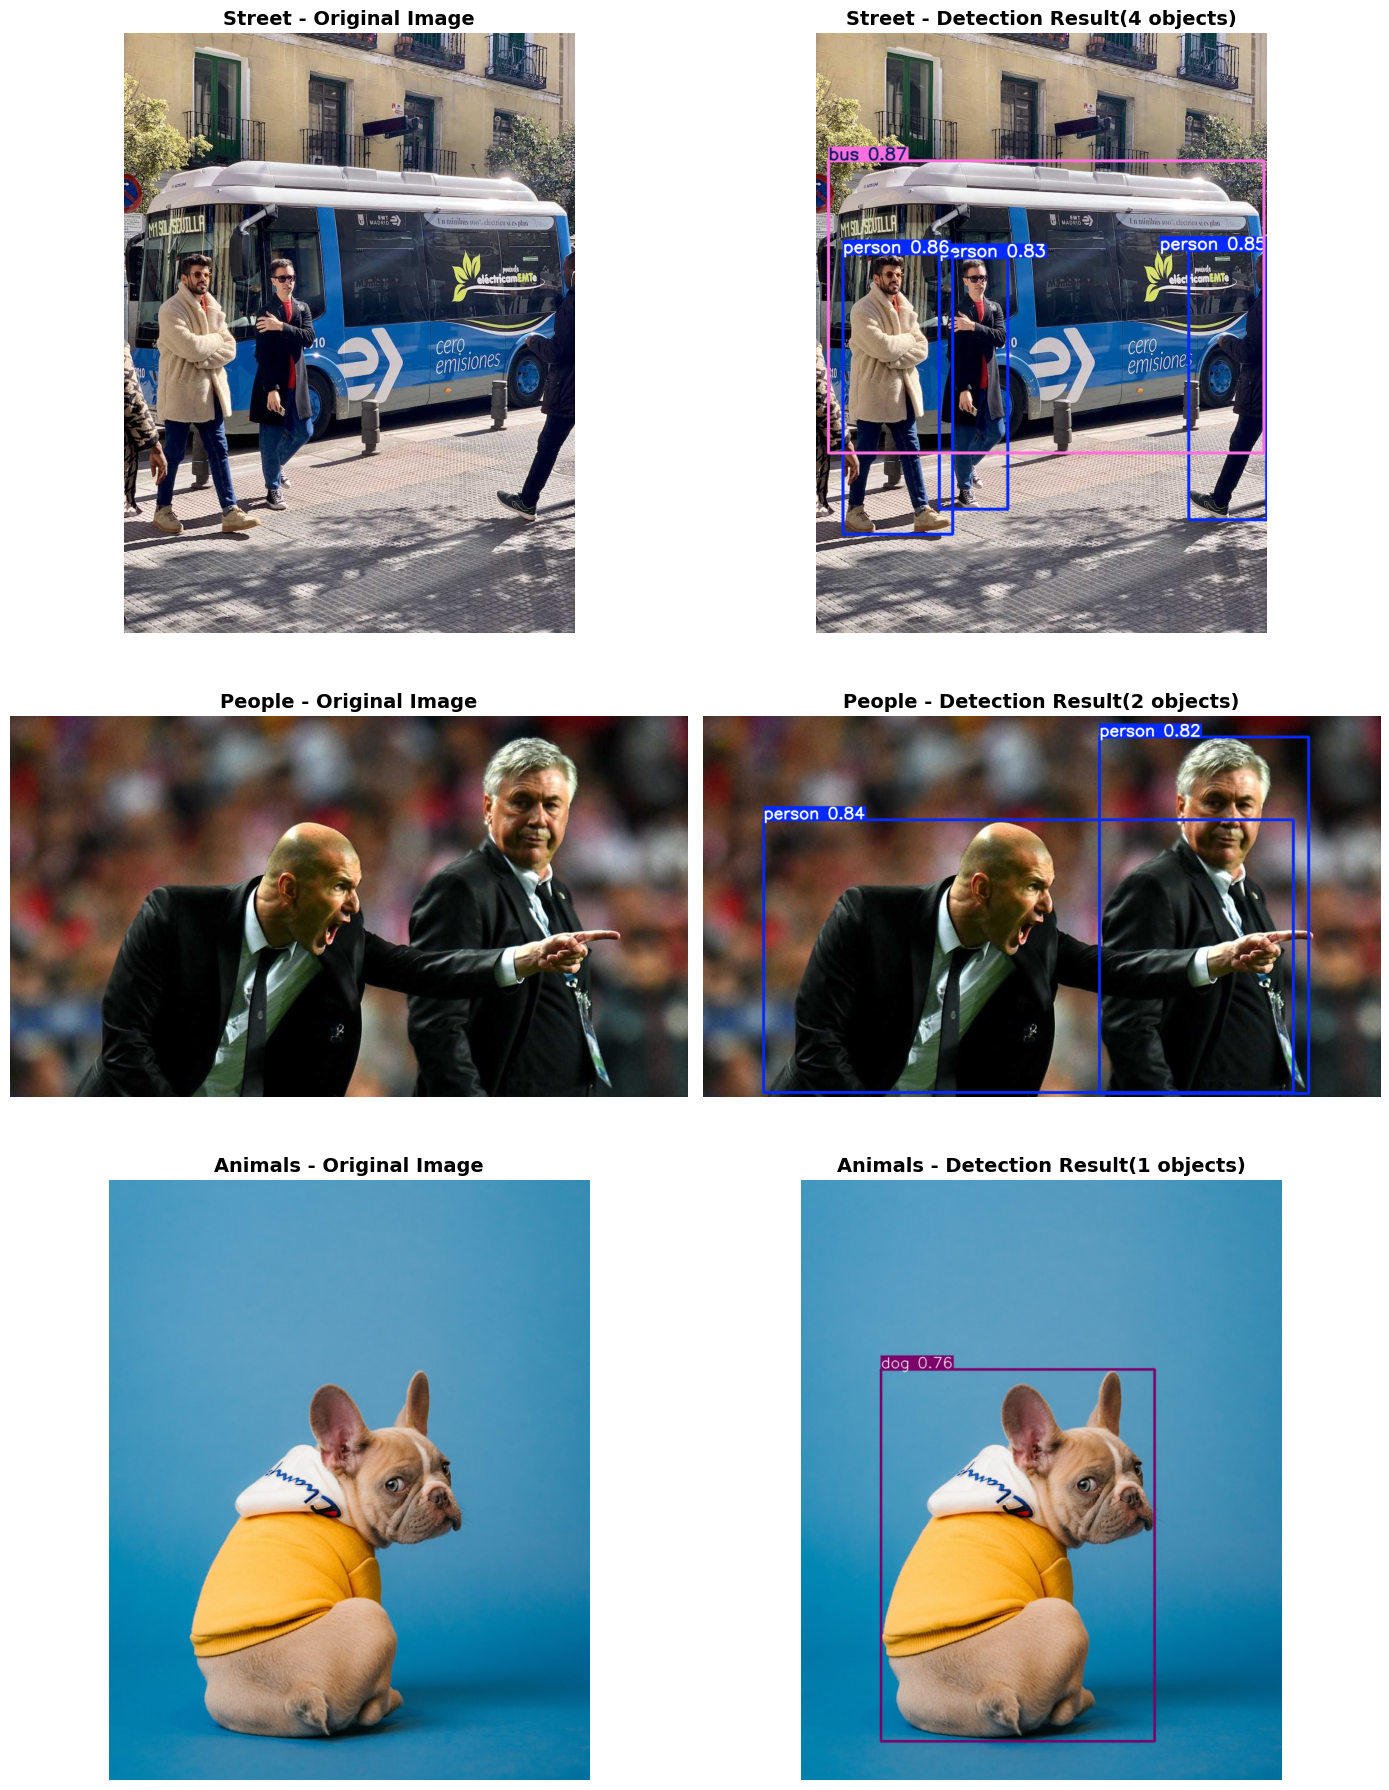

In [50]:
fig, axes = plt.subplots(len(images), 2, figsize=(14,6*len(images)))

if len(images) == 1:
    axes = axes.reshape(1,-1)

for idx, (name, img) in enumerate(images.items()):
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'{name.capitalize()} - Original Image',fontsize=14,fontweight='bold')
    axes[idx, 0].axis('off')

    results = model(img, conf=0.5)
    result_img = results[0].plot()
    axes[idx, 1].imshow(cv2.cvtColor(result_img,cv2.COLOR_BGR2RGB))
    axes[idx, 1].set_title(f'{name.capitalize()} - Detection Result({len(results[0].boxes)} objects)',fontsize=14,fontweight='bold')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

In [53]:
# 클래스 별 통계 분석

# 모든 이미지에서 검출 수행
all_detections = {}

for name, img in images.items():
    results = model(img, conf=0.5)
    boxes = results[0].boxes

    detections = []
    for box in boxes:
        cls = int(box.cls[0].cpu().item())
        conf = box.conf[0].cpu().item()
        detections.append({
            'class' : class_names[cls],
            'confidence' : conf
        })

    all_detections[name] = detections

from collections import Counter

for name, detections in all_detections.items():
    print(f'\n{name.upper()} 이미지')
    class_counts = Counter([det['class'] for det in detections])
    for cls, count in class_counts.most_common():
        avg_conf = np.mean([det['confidence'] for det in detections if det['class'] == cls])
        print(f'-{cls}: {count}개 (평균 confidence: {avg_conf:.3f})')


0: 640x480 3 persons, 1 bus, 3.0ms
Speed: 13.1ms preprocess, 3.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 2 persons, 2.8ms
Speed: 0.7ms preprocess, 2.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 640x512 1 dog, 2.4ms
Speed: 0.9ms preprocess, 2.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 512)

STREET 이미지
-person: 3개 (평균 confidence: 0.848)
-bus: 1개 (평균 confidence: 0.873)

PEOPLE 이미지
-person: 2개 (평균 confidence: 0.826)

ANIMALS 이미지
-dog: 1개 (평균 confidence: 0.758)


In [ ]:
# 커스텀 시각화
def draw_custom_boxes(image, results, conf_threshold=0.5):
    img_np = np.array(image).copy()
    boxes = results[0].boxes

    # 색상 팔레트 (클래스별)
    np.random.seed(42)
    colors = {cls: tuple(np.random.randint(0, 255, 3).tolist())
              for cls in range(len(class_names))}

    for box in boxes:
        conf = box.conf[0].cpu().item()
        if conf < conf_threshold:
            continue

        # 박스 정보
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls = int(box.cls[0].cpu().item())
        class_name = class_names[cls]
        color = colors[cls]

        # 박스 그리기
        cv2.rectangle(img_np, (x1, y1), (x2, y2), color, 3)

        # 레이블 배경
        label = f'{class_name} {conf:.2f}'
        (text_w, text_h), _ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img_np, (x1, y1 - text_h - 10),
                     (x1 + text_w, y1), color, -1)

        # 레이블 텍스트
        cv2.putText(img_np, label, (x1, y1 - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_np


0: 640x480 3 persons, 1 bus, 1 stop sign, 2.4ms
Speed: 19.9ms preprocess, 2.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


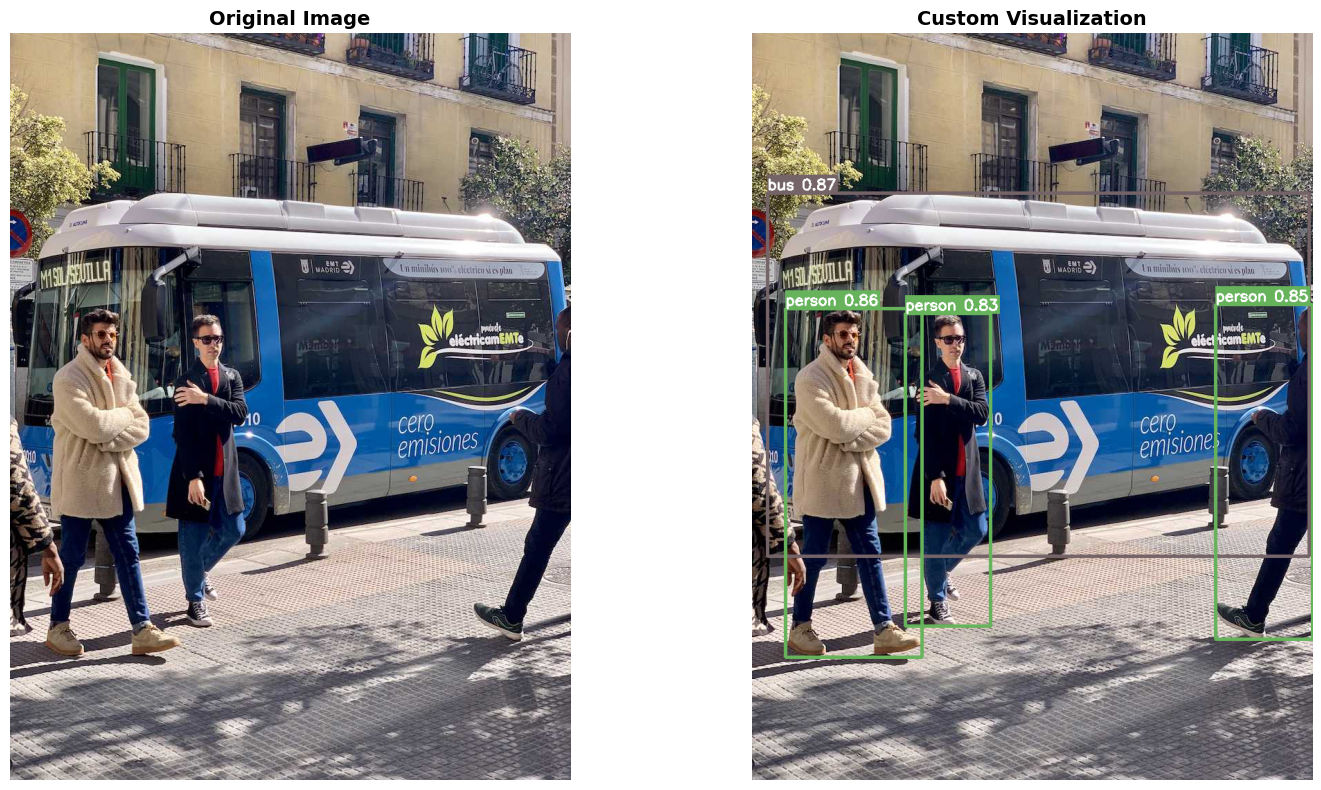

In [56]:
# 커스텀 시각화 적용
img_name = list(images.keys())[0]
test_img = images[img_name]
results = model(test_img)

custom_img = draw_custom_boxes(test_img, results, conf_threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(test_img)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(custom_img)
axes[1].set_title('Custom Visualization', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [69]:
model_info = {
    'YOLOv8n': {'params': '3.2M', 'mAP': 37.3, 'speed': '80+ FPS'},
    'YOLOv8s': {'params': '11.2M', 'mAP': 44.9, 'speed': '50+ FPS'},
    'YOLOv8m': {'params': '25.9M', 'mAP': 50.2, 'speed': '30+ FPS'},
    'YOLOv8l': {'params': '43.7M', 'mAP': 52.9, 'speed': '20+ FPS'},
    'YOLOv8x': {'params': '68.2M', 'mAP': 53.9, 'speed': '15+ FPS'},
}

model_info.items()

print(f'{'model':^10}|{'params':^10}|{'mAP':^10}|{'speed':^10}')
for model_name, info in model_info.items():
    print(f'{model_name:^10}|{info['params']:^10}|{info['mAP']:^9}%|{info['speed']:^10}')

  model   |  params  |   mAP    |  speed   
 YOLOv8n  |   3.2M   |  37.3   %| 80+ FPS  
 YOLOv8s  |  11.2M   |  44.9   %| 50+ FPS  
 YOLOv8m  |  25.9M   |  50.2   %| 30+ FPS  
 YOLOv8l  |  43.7M   |  52.9   %| 20+ FPS  
 YOLOv8x  |  68.2M   |  53.9   %| 15+ FPS  


In [61]:
# 배치 추론 (여러 이미지 동시 처리)

import time

# 이미지 리스트 준비
img_list = list(images.values())

# 단일 추론
start_time = time.time()
for img in img_list:
    _ = model(img, verbose=False)
single_time = time.time() - start_time

# 배치 추론
start_time = time.time()
_ = model(img_list, verbose=False)
batch_time = time.time() - start_time

print(f"단일 추론: {single_time:.3f}초 ({len(img_list)}개 이미지)")
print(f"배치 추론: {batch_time:.3f}초 ({len(img_list)}개 이미지)")
print(f"속도 향상: {single_time/batch_time:.2f}배")

단일 추론: 0.036초 (3개 이미지)
배치 추론: 0.030초 (3개 이미지)
속도 향상: 1.19배



파일 선택 창이 열립니다...
이미지 업로드 완료: /home/kim/Desktop/AI_cours/data/cat_on_a_laptop.jpg
크기: (1200, 900)


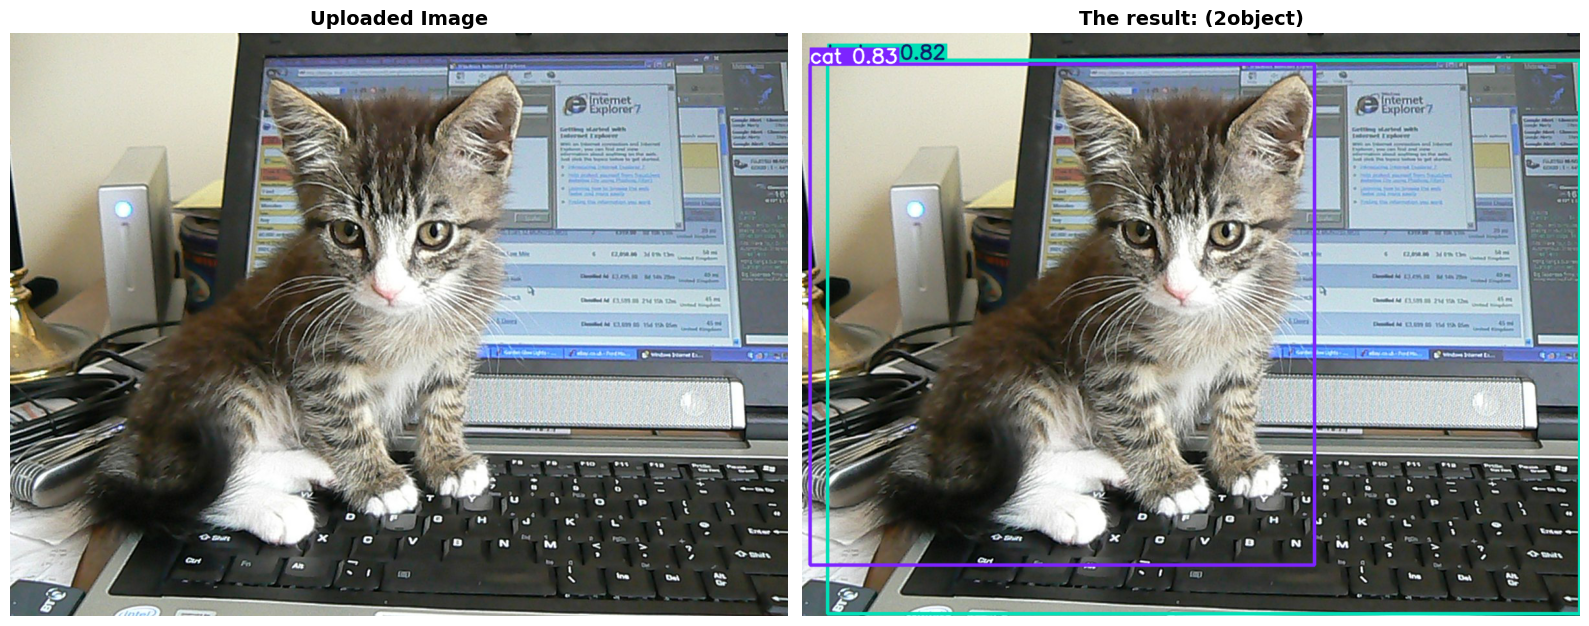


검출된 객체:
  1. cat: 0.827
  2. laptop: 0.821


In [63]:
# Colab 파일 업로드 기능


# from google.colab import files


print("\n파일 선택 창이 열립니다...")
# uploaded = files.upload()


# if uploaded:
    # 업로드된 첫 번째 이미지 사용
img_path = '/home/kim/Desktop/AI_cours/data/cat_on_a_laptop.jpg' # list(uploaded.keys())[0]
user_img = Image.open(img_path).convert('RGB')


print(f"이미지 업로드 완료: {img_path}")
print(f"크기: {user_img.size}")


# 검출 수행
results = model(user_img, conf=0.5)
result_img = results[0].plot()


# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(user_img)
axes[0].set_title('Uploaded Image', fontsize=14, fontweight='bold')
axes[0].axis('off')


axes[1].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'The result: ({len(results[0].boxes)}object)',
                    fontsize=14, fontweight='bold')
axes[1].axis('off')


plt.tight_layout()
plt.show()


# 검출 상세 정보
print("\n검출된 객체:")
for i, box in enumerate(results[0].boxes):
    cls = int(box.cls[0].cpu().item())
    conf = box.conf[0].cpu().item()
    print(f"  {i+1}. {class_names[cls]}: {conf:.3f}")